In [1]:
import polars as pl
from libs.overnight_range import plot_overnight_range
from libs.overnight_range.breakout import OvernightRangeBreakoutConfig
from libs.overnight_range.breakout import build_overnight_range_breakout_ledger
from datetime import date, datetime, time, timedelta
import matplotlib.pyplot as plt

In [2]:
path = r'C:\Code\Trading\2026\ml\data\minute_bars_gbpusd.parquet'
data = pl.read_parquet(path)
data = data.filter(pl.col('timestamp') < pl.datetime(2020,1,1, time_zone='UTC'))
# data = data.filter(pl.col("close_time") < pl.datetime(2025, 1, 1, time_zone='UTC'))

In [14]:
breakout_config = OvernightRangeBreakoutConfig(range_start=time(0,0),
                                               range_end=time(7,0),
                                               exit_time=time(17,0),
                                               pip_size=0.0001,
                                               buffer_pips=2,
                                               stop_range_multiple=1.0,
                                               target_range_multiple=1.0
                                               )

In [15]:
trades.filter(~pl.col("exit_reason").is_in(['stop','target','not_entered_no_range_data','not_entered_no_breakout']))

session_date,range_start,range_end,exit_time,range_expected_minutes,range_observed_minutes,range_coverage,trade_expected_minutes,trade_observed_minutes,trade_coverage,range_high,range_low,range_size,range_pips,long_trigger,short_trigger,status,side,breakout_timestamp,entry_timestamp,entry_price,stop_price,target_price,exit_timestamp,exit_price,exit_reason,gross_pnl,gross_pnl_pips,r_multiple
date,"datetime[μs, Europe/London]","datetime[μs, Europe/London]","datetime[μs, Europe/London]",i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,"datetime[μs, UTC]",f64,str,f64,f64,f64
2003-05-15,2003-05-15 00:00:00 BST,2003-05-15 07:00:00 BST,2003-05-15 17:00:00 BST,420,360,0.857143,600,600,1.0,1.61786,1.612375,0.005485,54.85,1.61806,1.612175,"""entered""","""long""",2003-05-15 09:14:00 UTC,2003-05-15 09:15:00 UTC,1.618,1.615258,1.62897,2003-05-15 15:59:00 UTC,1.62346,"""time""",0.00546,54.6,1.990884
2003-05-26,2003-05-26 00:00:00 BST,2003-05-26 07:00:00 BST,2003-05-26 17:00:00 BST,420,420,1.0,600,600,1.0,1.64108,1.63259,0.00849,84.9,1.64128,1.63239,"""entered""","""long""",2003-05-26 09:47:00 UTC,2003-05-26 09:48:00 UTC,1.64046,1.636215,1.65744,2003-05-26 15:59:00 UTC,1.63815,"""time""",-0.00231,-23.1,-0.54417
2003-06-10,2003-06-10 00:00:00 BST,2003-06-10 07:00:00 BST,2003-06-10 17:00:00 BST,420,420,1.0,600,600,1.0,1.64793,1.64122,0.00671,67.1,1.64813,1.64102,"""entered""","""long""",2003-06-10 06:01:00 UTC,2003-06-10 06:02:00 UTC,1.64813,1.644775,1.66155,2003-06-10 15:59:00 UTC,1.64899,"""time""",0.00086,8.6,0.256334
2003-06-26,2003-06-26 00:00:00 BST,2003-06-26 07:00:00 BST,2003-06-26 17:00:00 BST,420,420,1.0,600,600,1.0,1.67392,1.66897,0.00495,49.5,1.67412,1.66877,"""entered""","""short""",2003-06-26 06:14:00 UTC,2003-06-26 06:15:00 UTC,1.66853,1.671005,1.65863,2003-06-26 15:59:00 UTC,1.66313,"""time""",0.0054,54.0,2.181818
2003-07-22,2003-07-22 00:00:00 BST,2003-07-22 07:00:00 BST,2003-07-22 17:00:00 BST,420,420,1.0,600,540,0.9,1.60073,1.59459,0.00614,61.4,1.60093,1.59439,"""entered""","""long""",2003-07-22 08:01:00 UTC,2003-07-22 08:02:00 UTC,1.60088,1.59781,1.61316,2003-07-22 15:59:00 UTC,1.59987,"""time""",-0.00101,-10.1,-0.32899
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2019-10-30,2019-10-30 00:00:00 GMT,2019-10-30 07:00:00 GMT,2019-10-30 17:00:00 GMT,420,300,0.714286,600,60,0.1,1.28827,1.285815,0.002455,24.55,1.28847,1.285615,"""entered""","""long""",2019-10-30 10:00:00 UTC,2019-10-30 10:01:00 UTC,1.28866,1.2874325,1.29357,2019-10-30 10:59:00 UTC,1.28943,"""time""",0.00077,7.7,0.627291
2019-11-28,2019-11-28 00:00:00 GMT,2019-11-28 07:00:00 GMT,2019-11-28 17:00:00 GMT,420,300,0.714286,600,300,0.5,1.295095,1.292295,0.0028,28.0,1.295295,1.292095,"""entered""","""short""",2019-11-28 13:00:00 UTC,2019-11-28 13:01:00 UTC,1.29153,1.29293,1.28593,2019-11-28 16:59:00 UTC,1.2907,"""time""",0.00083,8.3,0.592857
2019-12-13,2019-12-13 00:00:00 GMT,2019-12-13 07:00:00 GMT,2019-12-13 17:00:00 GMT,420,300,0.714286,600,540,0.9,1.3508,1.343005,0.007795,77.95,1.351,1.342805,"""entered""","""short""",2019-12-13 07:26:00 UTC,2019-12-13 07:27:00 UTC,1.34241,1.3463075,1.32682,2019-12-13 16:59:00 UTC,1.33471,"""time""",0.0077,77.0,1.975625


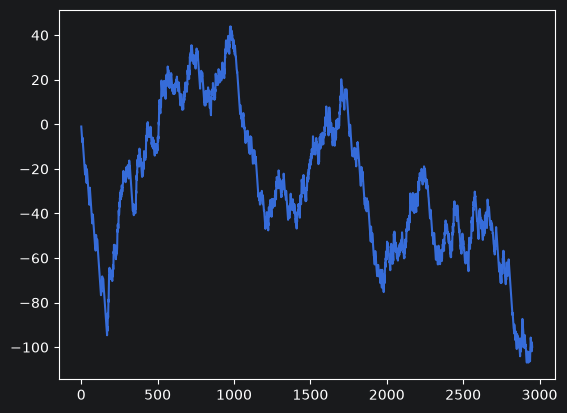

In [16]:
plt.plot(trades.filter(pl.col("r_multiple").is_not_null())[('r_multiple')].cum_sum())

In [9]:
figure, output_path = plot_overnight_range('2023-05-18', data)
output_path

WindowsPath('C:/Code/Trading/2026/ml/plots/overnight_range/overnight_range_2023-05-18.html')